# DESAFIO 13 - Classificação de Texto de Notícias
**Importante:** É necessário a instalação do arquivo e importação no notebook

***Link para download:*** https://www.kaggle.com/datasets/rmisra/news-category-dataset

**Descrição para download e Importação:**

1.   Abrir no link e clicar em "Download"
2.   De volta no notebook, clique com o mouse direito no ícone de pasta
3.   Clique no primeiro ícone para fazer o upload do arquivo baixado

**Descrição de Separação:**
Para separação de blocos foi utilizado númeração, como existirá sub-blocos seguirá o padrão de o numero do bloco principal seguido de . e o número segundário por exemplo 1.2, 1.3, 1.4

## 1. Importação

In [1]:
# ── Manipulação e visualização de dados ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# ── Extração de features de texto ─────────────────────────────────────────────
# TfidfVectorizer: converte texto em matriz numérica ponderada pela importância do termo
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Divisão e validação cruzada ────────────────────────────────────────────────
# train_test_split: divide os dados em treino/validação/teste
# StratifiedKFold: k-fold que mantém a proporção de classes em cada fold
# cross_validate: executa a CV e retorna múltiplas métricas simultaneamente
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate

# ── Modelos de classificação ───────────────────────────────────────────────────
from sklearn.naive_bayes import MultinomialNB           # Naive Bayes para dados de frequência
from sklearn.linear_model import LogisticRegression     # Regressão logística multiclasse
from sklearn.svm import LinearSVC                       # SVM linear — eficiente para texto esparso

# ── Métricas de avaliação ──────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay, confusion_matrix
)
from sklearn.metrics import precision_recall_fscore_support

# ── Utilitários para texto e visualização ─────────────────────────────────────
from wordcloud import WordCloud   # nuvem de palavras
import re                         # expressões regulares para limpeza de texto
import warnings
from collections import Counter   # contagem de frequência de palavras
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)  # semente fixa para reprodutibilidade dos experimentos

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento de Dados

In [2]:
# Carrega o dataset no formato JSON Lines (cada linha é um objeto JSON independente).
# O arquivo contém 209.527 manchetes de notícias do HuffPost com suas categorias.
df_raw = pd.read_json('/content/News_Category_Dataset_v3.json', lines=True)

print('=== DATASET CARREGADO ===')
print(f'Total de registros: {len(df_raw):,}')
print(f'Colunas: {list(df_raw.columns)}')
print()
print(df_raw[['headline', 'category']].head())

# Exibe tipos de dados e contagem de não-nulos — confirma ausência de dados faltantes
df_raw.info()

=== DATASET CARREGADO ===
Total de registros: 209,527
Colunas: ['link', 'headline', 'category', 'short_description', 'authors', 'date']

                                            headline   category
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY
3  The Funniest Tweets From Parents This Week (Se...  PARENTING
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 no

## 3. EDA (Análise Exploratória)

In [3]:
# O dataset possui 42 categorias. Trabalhar com todas aumentaria a complexidade
# e reduziria o volume de amostras por classe. Selecionamos as 5 mais frequentes
# para garantir dados suficientes e um problema de classificação bem definido.
print('=== DISTRIBUICAO COMPLETA DE CATEGORIAS ===')
distribuicao = df_raw['category'].value_counts()
print(f'Total de categorias unicas: {distribuicao.nunique()}')
print()

# As 5 categorias com mais notícias serão o alvo da classificação
top5_categorias = distribuicao.head(5).index.tolist()
print('Top 5 categorias mais frequentes:')
for i, cat in enumerate(top5_categorias, 1):
    print(f'  {i}. {cat}: {distribuicao[cat]:,} noticias')

# Mantém apenas as linhas pertencentes às 5 categorias selecionadas
df = df_raw[df_raw['category'].isin(top5_categorias)].copy().reset_index(drop=True)
print(f'\nDataset filtrado: {len(df):,} registros')

# ── TRATAMENTO DE INCONSISTÊNCIAS: remoção de manchetes duplicadas ─────────────
# O comando .duplicated() marca linhas cujo 'headline' já apareceu antes.
# Por que isso importa: o News Category Dataset contém manchetes repetidas. Se uma
# cópia cair no TREINO e outra no TESTE, o modelo "vê" o mesmo exemplo nas duas etapas
# (data leakage), inflando artificialmente as métricas. Por isso removemos duplicatas
# AGORA — antes de qualquer divisão treino/validação/teste.
n_antes = len(df)
df = df.drop_duplicates(subset='headline').reset_index(drop=True)
print(f'Duplicatas removidas: {n_antes - len(df):,}')
print(f'Dataset final (sem duplicatas): {len(df):,} registros')

=== DISTRIBUICAO COMPLETA DE CATEGORIAS ===
Total de categorias unicas: 42

Top 5 categorias mais frequentes:
  1. POLITICS: 35,602 noticias
  2. WELLNESS: 17,945 noticias
  3. ENTERTAINMENT: 17,362 noticias
  4. TRAVEL: 9,900 noticias
  5. STYLE & BEAUTY: 9,814 noticias

Dataset filtrado: 90,623 registros
Duplicatas removidas: 728
Dataset final (sem duplicatas): 89,895 registros


#### 3.1 - Visualização da Distribução

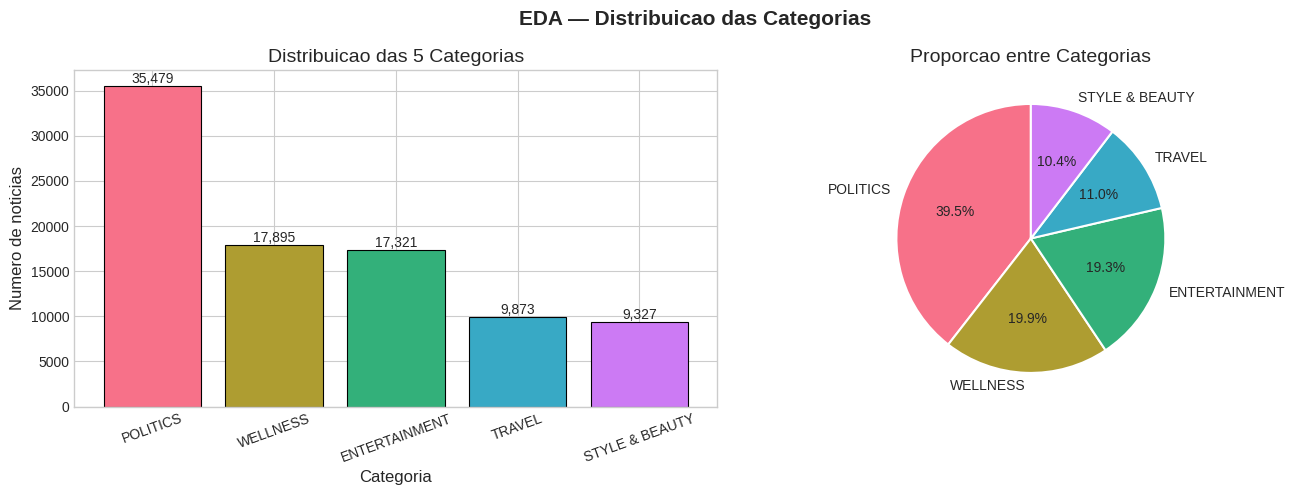

Razao max/min entre categorias: 3.80x
Dataset DESBALANCEADO — estratificacao necessaria na divisao.


In [4]:
# Visualiza a distribuição das categorias para identificar desbalanceamento de classes.
# Datasets desbalanceados exigem estratificação na divisão treino/validação/teste
# para garantir que todas as classes estejam representadas em cada conjunto.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contagem_cat = df['category'].value_counts()
cores = sns.color_palette('husl', len(contagem_cat))

# Gráfico de barras — mostra contagem absoluta por categoria
barras = axes[0].bar(contagem_cat.index, contagem_cat.values,
                     color=cores, edgecolor='black', linewidth=0.8)
axes[0].set_xlabel('Categoria', fontsize=12)
axes[0].set_ylabel('Numero de noticias', fontsize=12)
axes[0].set_title('Distribuicao das 5 Categorias', fontsize=14)
axes[0].tick_params(axis='x', rotation=20)
for barra in barras:
    h = barra.get_height()
    axes[0].text(barra.get_x() + barra.get_width()/2, h + 0.3,
                 f'{int(h):,}', ha='center', va='bottom', fontsize=10)

# Gráfico de pizza — mostra proporção relativa entre categorias
axes[1].pie(contagem_cat.values, labels=contagem_cat.index,
            autopct='%1.1f%%', startangle=90, colors=cores,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporcao entre Categorias', fontsize=14)

plt.suptitle('EDA — Distribuicao das Categorias', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Razão max/min: mede o grau de desbalanceamento entre a maior e a menor classe
razao = contagem_cat.max() / contagem_cat.min()
print(f'Razao max/min entre categorias: {razao:.2f}x')
if razao < 1.5:
    print('Dataset BALANCEADO — otimo para treinar sem vies de classe.')
else:
    print('Dataset DESBALANCEADO — estratificacao necessaria na divisao.')

#### 3.2 - Tamanho Médio das Manchetes

=== TAMANHO MEDIO DAS MANCHETES POR CATEGORIA ===
               n_palavras         n_chars         
                     mean min max    mean min  max
category                                          
ENTERTAINMENT        10.7   1  44    64.7   5  295
POLITICS             10.3   0  27    64.4   0  189
STYLE & BEAUTY       10.5   1  24    64.5   7  135
TRAVEL                8.3   1  28    49.9   3  178
WELLNESS              8.1   1  24    48.4   4  133


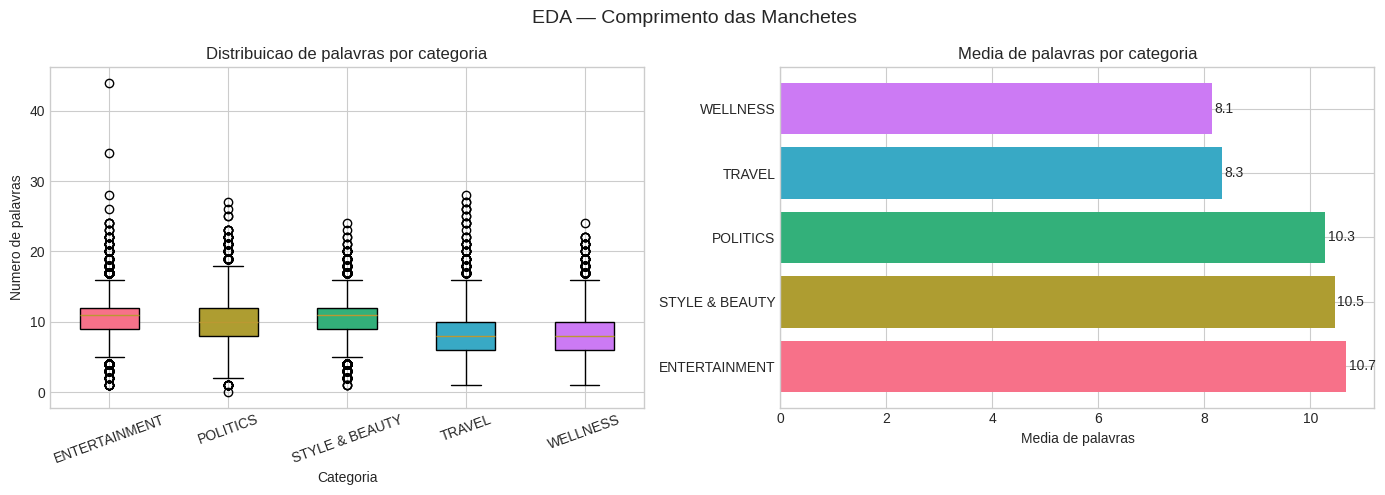

In [5]:
# O número de palavras por manchete pode revelar diferenças entre categorias:
# ex: títulos de entretenimento tendem a ser mais curtos e diretos,
# enquanto manchetes políticas podem ser mais longas e descritivas.
# Essa análise ajuda a entender a natureza do texto antes da vetorização.

df['n_palavras'] = df['headline'].apply(lambda x: len(str(x).split()))
df['n_chars']    = df['headline'].apply(lambda x: len(str(x)))

print('=== TAMANHO MEDIO DAS MANCHETES POR CATEGORIA ===')
stats = df.groupby('category')[['n_palavras', 'n_chars']].agg(['mean', 'min', 'max']).round(1)
print(stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot — mostra distribuição completa (mediana, quartis, outliers) por categoria
cats_ord = sorted(df['category'].unique())
data_box = [df[df['category'] == c]['n_palavras'].values for c in cats_ord]
bp = axes[0].boxplot(data_box, labels=cats_ord, patch_artist=True)
for patch, cor in zip(bp['boxes'], sns.color_palette('husl', len(cats_ord))):
    patch.set_facecolor(cor)
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Numero de palavras')
axes[0].set_title('Distribuicao de palavras por categoria')
axes[0].tick_params(axis='x', rotation=20)

# Barras de média — permite comparação direta do comprimento médio entre categorias
media_palavras = df.groupby('category')['n_palavras'].mean().sort_values(ascending=False)
axes[1].barh(media_palavras.index, media_palavras.values,
             color=sns.color_palette('husl', len(media_palavras)))
axes[1].set_xlabel('Media de palavras')
axes[1].set_title('Media de palavras por categoria')
for i, v in enumerate(media_palavras.values):
    axes[1].text(v + 0.05, i, f'{v:.1f}', va='center')

plt.suptitle('EDA — Comprimento das Manchetes', fontsize=14)
plt.tight_layout()
plt.show()

#### 3.3 - Palavras Mais Frequentes Por Categoria

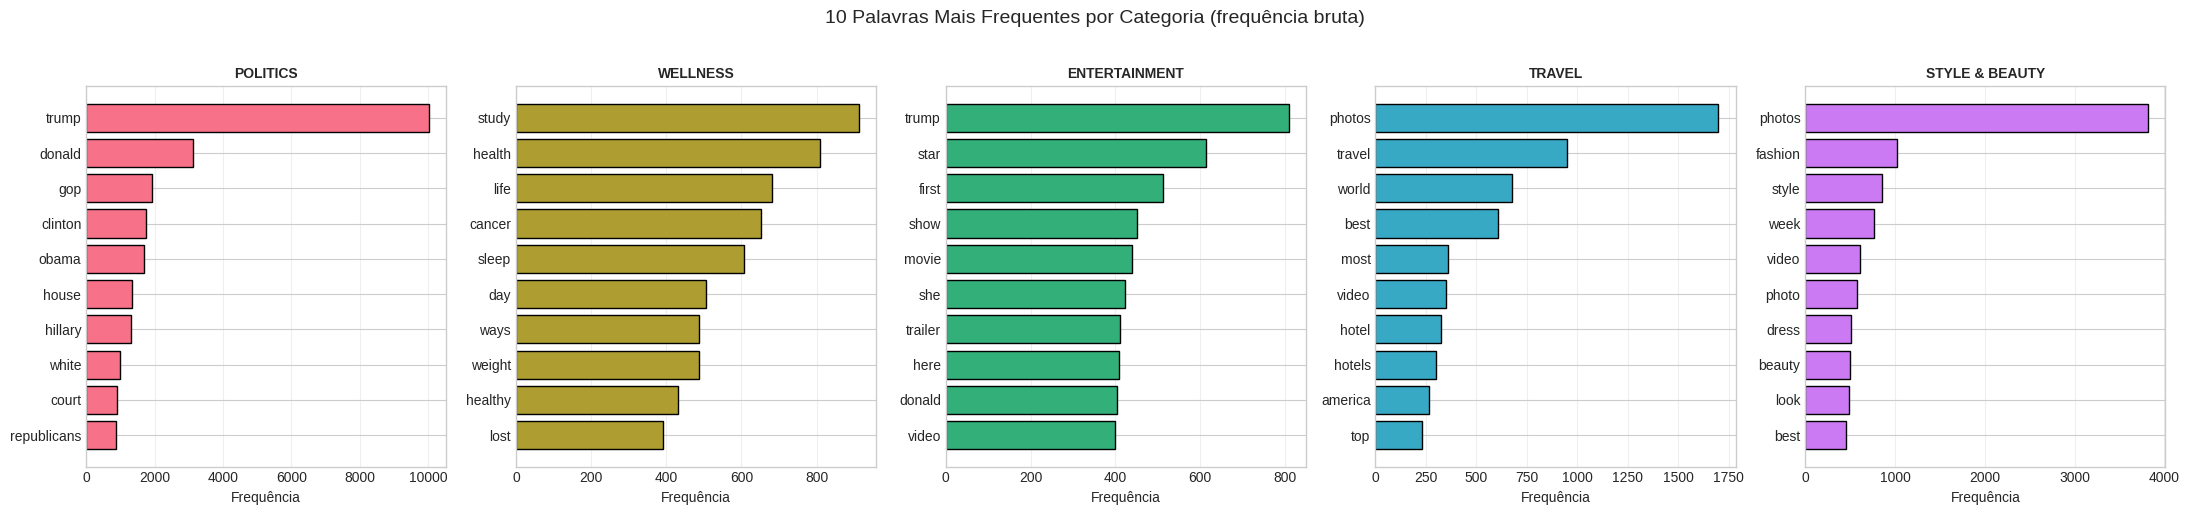

In [6]:
# EDA exploratória: identifica quais palavras aparecem com mais FREQUÊNCIA em cada categoria.
# Nota: esta análise é baseada em contagem bruta — palavras comuns entre categorias
# podem aparecer sem alto poder discriminativo. A análise baseada nos coeficientes
# do modelo treinado (seção 7.3) é mais precisa para identificar termos discriminativos.

from collections import Counter

stop_words_simples = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','have','has','had','do','does','did',
    'will','would','could','should','may','might','its','it','this','that',
    'as','by','from','about','after','before','their','they','them','new',
    'you','your','her','his','how','what','who','why','when','says','after',
    'over','up','out','not','all','more','can','one','than','into','so','no'
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
cores = sns.color_palette('husl', 5)

for ax, cat, cor in zip(axes, top5_categorias, cores):
    # Concatena todas as manchetes da categoria e tokeniza (apenas letras)
    textos = df[df['category'] == cat]['headline'].str.lower()
    words = []
    for t in textos:
        words += [w for w in re.findall(r'[a-z]+', t)
                  if w not in stop_words_simples and len(w) > 2]
    # Seleciona as 10 palavras mais frequentes por contagem bruta
    top10 = Counter(words).most_common(10)
    palavras, contagens = zip(*top10)
    ax.barh(list(palavras)[::-1], list(contagens)[::-1], color=cor, edgecolor='black')
    ax.set_title(cat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Frequência')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('10 Palavras Mais Frequentes por Categoria (frequência bruta)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 3.3.1 - Nuvem de Palavras Mais Frequentes Por Categoria

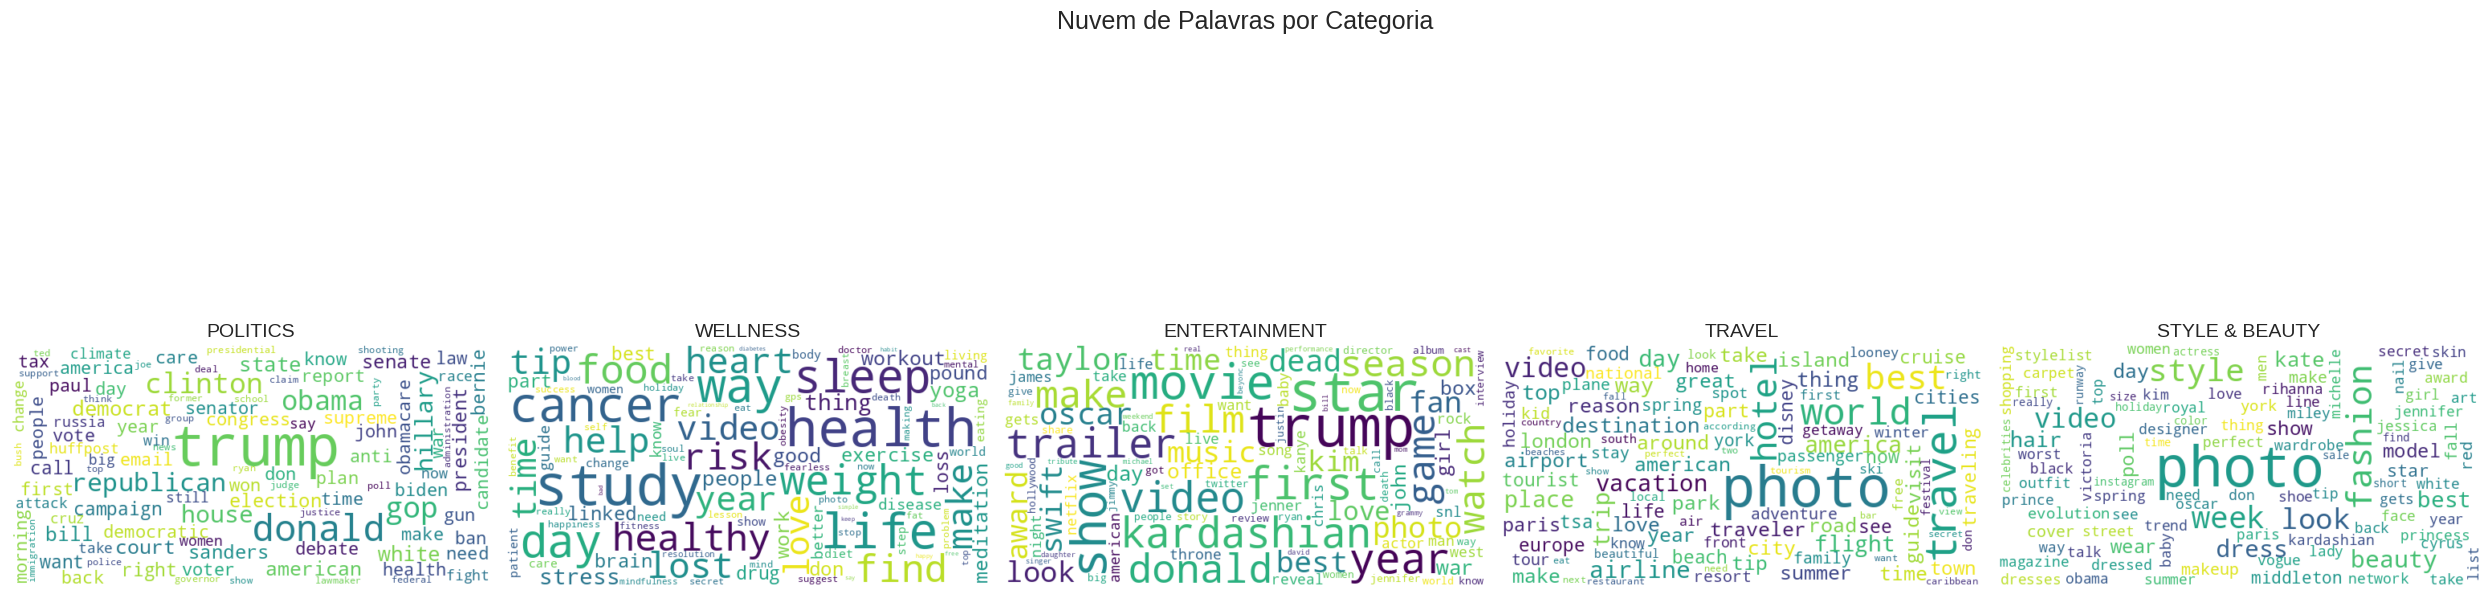

In [7]:
# Nuvem de palavras: visualização alternativa das palavras mais frequentes.
# O tamanho de cada palavra é proporcional à sua frequência na categoria,
# facilitando a identificação rápida dos temas dominantes em cada classe.
stop_words_simples = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','have','has','had','do','does','did',
    'will','would','could','should','may','might','its','it','this','that',
    'as','by','from','about','after','before','their','they','them','new',
    'you','your','her','his','how','what','who','why','when','says','after',
    'over','up','out','not','all','more','can','one','than','into','so','no'
}

fig, axes = plt.subplots(1, 5, figsize=(25, 8))
axes = axes.flatten()

for i, cat in enumerate(top5_categorias):
    headlines = df[df['category'] == cat]['headline'].str.lower()

    all_words = []
    for h in headlines:
        all_words.extend([w for w in re.findall(r'[a-z]+', h)
                          if w not in stop_words_simples and len(w) > 2])

    # Junta todas as palavras em uma string para a WordCloud processar
    text_for_wordcloud = ' '.join(all_words)

    wordcloud = WordCloud(background_color='white',
                          max_words=100,
                          max_font_size=70,
                          collocations=False,
                          height=300,
                          width=600).generate(text_for_wordcloud)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(cat, fontsize=14)
    axes[i].axis('off')

plt.suptitle('Nuvem de Palavras por Categoria', fontsize=18, y=1.05)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## 4. Pré-Processamento

In [8]:
# Pré-processamento: padroniza as manchetes antes da vetorização.
# O TF-IDF é sensível a maiúsculas/minúsculas e pontuação; sem limpeza,
# 'Trump' e 'trump' seriam tratados como tokens distintos, inflando o vocabulário.
def limpar_texto(texto):
    # Converte para minúsculas — uniformiza tokens independente de capitalização
    texto = str(texto).lower()
    # Remove tudo que não seja letra (pontuação, números, símbolos especiais)
    texto = re.sub(r'[^a-z\s]', '', texto)
    # Colapsa múltiplos espaços em um único espaço e remove espaços nas bordas
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['headline_limpa'] = df['headline'].apply(limpar_texto)

# TRATAMENTO DE INCONSISTÊNCIAS: remove manchetes que ficaram VAZIAS após a limpeza
# (ex.: títulos compostos só por números/símbolos). Uma string vazia gera um vetor
# TF-IDF totalmente nulo, que não contribui para o aprendizado e pode atrapalhar.
n_antes = len(df)
df = df[df['headline_limpa'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Manchetes vazias removidas após limpeza: {n_antes - len(df):,}\n')

print('=== EXEMPLOS DE LIMPEZA ===')
for i in range(3):
    print(f'Original : {df["headline"].iloc[i]}')
    print(f'Limpa    : {df["headline_limpa"].iloc[i]}')
    print()

Manchetes vazias removidas após limpeza: 1

=== EXEMPLOS DE LIMPEZA ===
Original : Golden Globes Returning To NBC In January After Year Off-Air
Limpa    : golden globes returning to nbc in january after year offair

Original : Biden Says U.S. Forces Would Defend Taiwan If China Invaded
Limpa    : biden says us forces would defend taiwan if china invaded

Original : ‘Beautiful And Sad At The Same Time’: Ukrainian Cultural Festival Takes On A Deeper Meaning This Year
Limpa    : beautiful and sad at the same time ukrainian cultural festival takes on a deeper meaning this year



In [9]:
# Divisão estratificada 60/20/20 (treino / validação / teste).
# stratify=y garante que a proporção de cada categoria seja mantida nos três conjuntos,
# evitando viés por sub-representação de classes menores (TRAVEL, STYLE & BEAUTY).
# O conjunto de validação serve para comparar modelos antes de usar o teste final,
# enquanto o teste é reservado exclusivamente para a avaliação definitiva.
X = df['headline_limpa'].values
y = df['category'].values

# Passo 1: separa 20% para teste, mantendo 80% temporários
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Passo 2: dos 80% restantes, separa 25% (= 20% do total) para validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print('=== DIVISÃO 60/20/20 ===')
print(f'Treino    : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validação : {len(X_val):,} ({len(X_val)/len(X)*100:.0f}%)')
print(f'Teste     : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)')

=== DIVISÃO 60/20/20 ===
Treino    : 53,936 (60%)
Validação : 17,979 (20%)
Teste     : 17,979 (20%)


In [10]:
# TF-IDF (Term Frequency–Inverse Document Frequency): representa cada manchete como um
# vetor numérico onde o peso de cada palavra reflete sua importância no documento em
# relação ao corpus inteiro (palavras raras têm peso maior que palavras ubíquas).
#
# ngram_range=(1,2): captura unigramas ('trump') e bigramas ('white house')
# stop_words='english': remove palavras sem valor discriminativo (the, a, is...)
# min_df=2: ignora termos presentes em menos de 2 documentos (possível ruído/typo)
# max_df=0.95: ignora termos presentes em mais de 95% dos documentos (muito genéricos)
# max_features=50000: limita o vocabulário aos 50.000 termos mais relevantes
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    max_df=0.95,
    max_features=50000
)

# fit_transform: aprende o vocabulário no treino e transforma para matriz esparsa
# transform: aplica o mesmo vocabulário aprendido — sem reaprender — em val e teste.
# Isso evita data leakage: informações do val/teste não influenciam o vocabulário.
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print('=== VETORIZAÇÃO TF-IDF ===')
print(f'Vocabulário: {len(vectorizer.vocabulary_):,} termos')
print(f'Matriz treino : {X_train_tfidf.shape}')
print(f'Matriz val    : {X_val_tfidf.shape}')
print(f'Matriz teste  : {X_test_tfidf.shape}')

=== VETORIZAÇÃO TF-IDF ===
Vocabulário: 41,731 termos
Matriz treino : (53936, 41731)
Matriz val    : (17979, 41731)
Matriz teste  : (17979, 41731)


## 5. Comparação com outros modelos

### 5.1 Definição dos modelos

In [11]:
# Define os três modelos com seus hiperparâmetros.
#
# MultinomialNB: baseline probabilístico, rápido e interpretável.
#   alpha=0.1: suavização de Laplace reduzida (< 1.0). Como o TF-IDF gera um vocabulário
#              grande e ESPARSO, um alpha menor evita achatar demais o peso dos termos.
#
# LogisticRegression: modelo linear probabilístico com boa calibração de probabilidades.
#   C=5.0: regularização fraca (C alto = menos penalização), adequado para dados com
#          muitas features relevantes como TF-IDF.
#   solver='lbfgs', multi_class='multinomial': otimização direta para multiclasse.
#
# LinearSVC: SVM linear sem probabilidades nativas, muito eficiente para texto esparso.
#   C=1.0: regularização padrão L2.
#   max_iter=2000: aumentado pois o problema tem 42.410 features.
models = {
    'MultinomialNB': MultinomialNB(alpha=0.1),
    'LogisticRegression': LogisticRegression(
        # Obs.: o parâmetro multi_class foi REMOVIDO — desde o scikit-learn 1.5 ele está
        # depreciado (sai na 1.7). Com solver='lbfgs', o comportamento multinomial (softmax)
        # já é o padrão automático para problemas com mais de 2 classes.
        C=5.0, max_iter=1000, random_state=42, solver='lbfgs'
    ),
    'LinearSVC': LinearSVC(
        C=1.0, max_iter=2000, random_state=42
    )
}

print('Modelos definidos:')
for name, model in models.items():
    print(f'  - {name}: {model}')

Modelos definidos:
  - MultinomialNB: MultinomialNB(alpha=0.1)
  - LogisticRegression: LogisticRegression(C=5.0, max_iter=1000, random_state=42)
  - LinearSVC: LinearSVC(max_iter=2000, random_state=42)


### 5.2 Stratified K-Fold (k=3)

In [12]:
# Validação cruzada estratificada com k=3 folds sobre o conjunto de TREINO.
# StratifiedKFold mantém a proporção de classes em cada fold, evitando que um
# fold fique sem amostras de alguma categoria (problema crítico em classes menores).
# k=3 equilibra custo computacional e confiabilidade da estimativa de desempenho.
# Usamos cross_validate (em vez de cross_val_score) para calcular múltiplas métricas.
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Métricas macro: média não ponderada entre classes — penaliza igualmente
# erros em classes menores (TRAVEL, STYLE & BEAUTY) e maiores (POLITICS)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

cv_results = {}

print("Executando Stratified K-Fold (k=3) para cada modelo")
for name, model in models.items():
    print(f' {name} -> ')
    cv = cross_validate(
        model, X_train_tfidf, y_train,
        cv=skf, scoring=scoring, n_jobs=-1
    )
    # A média das métricas nos 3 folds representa o desempenho esperado em dados não vistos
    cv_results[name] = {
        'Acurácia': cv['test_accuracy'].mean(),
        'Precisão Macro': cv['test_precision_macro'].mean(),
        'Recall Macro': cv['test_recall_macro'].mean(),
        'F1-Score Macro': cv['test_f1_macro'].mean(),
    }
    print(f'Acurácia={cv["test_accuracy"].mean():.4f} | F1={cv["test_f1_macro"].mean():.4f}')

Executando Stratified K-Fold (k=3) para cada modelo
 MultinomialNB -> 
Acurácia=0.8622 | F1=0.8427
 LogisticRegression -> 
Acurácia=0.8718 | F1=0.8554
 LinearSVC -> 
Acurácia=0.8744 | F1=0.8590


In [13]:
# Tabela comparativa das médias de CV — facilita a seleção do melhor modelo
# antes de qualquer contato com o conjunto de teste
results_df = pd.DataFrame(cv_results).T.round(4)
print('Tabela comparativa - k=3 (médias dos folds de treino)')
print(results_df)

Tabela comparativa - k=3 (médias dos folds de treino)
                    Acurácia  Precisão Macro  Recall Macro  F1-Score Macro
MultinomialNB         0.8622          0.8565        0.8310          0.8427
LogisticRegression    0.8718          0.8707        0.8432          0.8554
LinearSVC             0.8744          0.8684        0.8511          0.8590


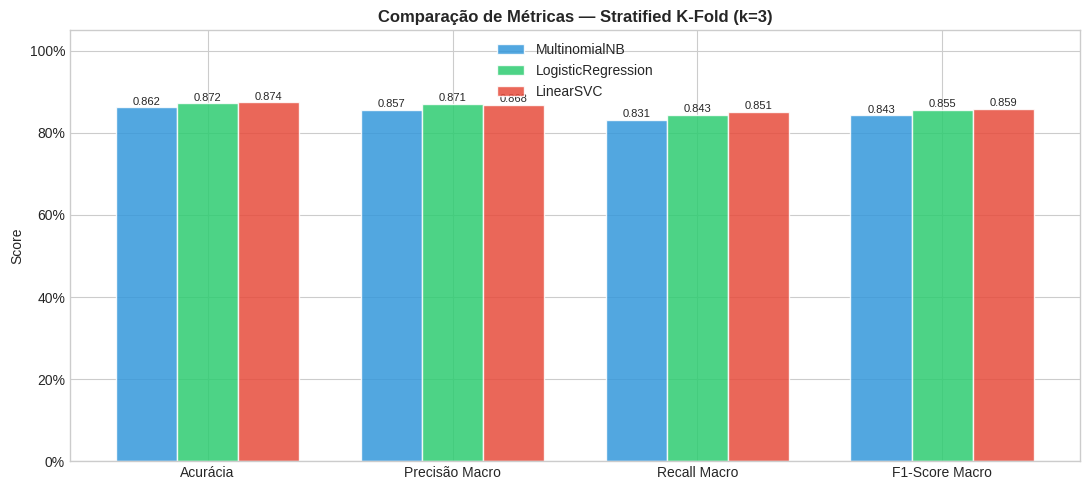

In [14]:
# Gráfico comparativo de todas as métricas para os 3 modelos.
# Permite identificar qual modelo é mais equilibrado entre precisão e recall (F1 Macro).
metrics = list(results_df.columns)
x = np.arange(len(metrics))
width = 0.25
model_colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i*width, row.values, width, label=name,
                  color=model_colors[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title('Comparação de Métricas — Stratified K-Fold (k=3)', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.tight_layout()
plt.savefig('fig_comparacao_modelos.png', bbox_inches='tight')
plt.show()

### 5.3 Avaliação final (Validação e Teste)

In [15]:
# Treina cada modelo no conjunto de treino completo (sem CV) e avalia em dois conjuntos:
# 1. Validação: usado para comparar e selecionar o melhor modelo (sem viés de seleção).
# 2. Teste: reservado para a avaliação definitiva — consultado apenas uma vez ao final.
# Essa separação garante que a escolha do modelo não seja influenciada pelo conjunto de teste.
test_results = {}
val_results  = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)

    # Avaliação no conjunto de VALIDAÇÃO — usado para selecionar o melhor modelo
    y_val_pred = model.predict(X_val_tfidf)
    val_results[name] = {
        'Acurácia': accuracy_score(y_val, y_val_pred),
        'Precisão Macro': precision_score(y_val, y_val_pred, average='macro'),
        'Recall Macro': recall_score(y_val, y_val_pred, average='macro'),
        'F1-Score Macro': f1_score(y_val, y_val_pred, average='macro'),
    }

    # Avaliação no conjunto de TESTE — resultado final definitivo
    y_pred = model.predict(X_test_tfidf)
    fitted_models[name] = (model, y_pred)
    test_results[name] = {
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão Macro': precision_score(y_test, y_pred, average='macro'),
        'Recall Macro': recall_score(y_test, y_pred, average='macro'),
        'F1-Score Macro': f1_score(y_test, y_pred, average='macro'),
    }

val_df  = pd.DataFrame(val_results).T.round(4)
test_df = pd.DataFrame(test_results).T.round(4)

print("=== Avaliação no Conjunto de VALIDAÇÃO ===")
print(val_df)
print()
print("=== Avaliação final no Conjunto de TESTE ===")
print(test_df)

=== Avaliação no Conjunto de VALIDAÇÃO ===
                    Acurácia  Precisão Macro  Recall Macro  F1-Score Macro
MultinomialNB         0.8691          0.8665        0.8391          0.8517
LogisticRegression    0.8830          0.8778        0.8593          0.8678
LinearSVC             0.8840          0.8757        0.8635          0.8693

=== Avaliação final no Conjunto de TESTE ===
                    Acurácia  Precisão Macro  Recall Macro  F1-Score Macro
MultinomialNB         0.8664          0.8611        0.8319          0.8452
LogisticRegression    0.8828          0.8751        0.8580          0.8658
LinearSVC             0.8851          0.8750        0.8632          0.8687


### 5.3.1 Comparativo CV × Validação × Teste

=== Comparativo F1-Score Macro: CV × Validação × Teste ===
                    CV-Treino (F1)  Validação (F1)  Teste (F1)
MultinomialNB               0.8427          0.8517      0.8452
LogisticRegression          0.8554          0.8678      0.8658
LinearSVC                   0.8590          0.8693      0.8687



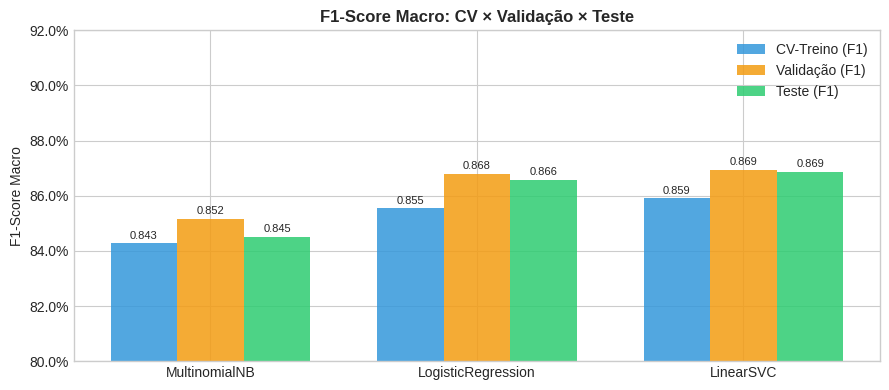

Análise: métricas consistentes entre CV, validação e teste indicam boa generalização.


In [16]:
# Compara as três etapas de avaliação: validação cruzada no treino,
# desempenho no conjunto de validação e desempenho no conjunto de teste.
# Métricas próximas entre as três etapas indicam que o modelo generalizou bem
# e não houve overfitting (memorização excessiva do conjunto de treino).

comparativo = pd.DataFrame({
    'CV-Treino (F1)': results_df['F1-Score Macro'],
    'Validação (F1)': val_df['F1-Score Macro'],
    'Teste (F1)':     test_df['F1-Score Macro'],
})
print('=== Comparativo F1-Score Macro: CV × Validação × Teste ===')
print(comparativo.round(4))
print()

# Gráfico de barras agrupadas para comparação visual das três etapas
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(comparativo))
w = 0.25
etapas = ['CV-Treino (F1)', 'Validação (F1)', 'Teste (F1)']
cores_etapas = ['#3498db', '#f39c12', '#2ecc71']

for i, (etapa, cor) in enumerate(zip(etapas, cores_etapas)):
    bars = ax.bar(x + i*w, comparativo[etapa], w, label=etapa, color=cor, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels(comparativo.index)
ax.set_ylim(0.8, 0.92)
ax.set_title('F1-Score Macro: CV × Validação × Teste', fontweight='bold')
ax.set_ylabel('F1-Score Macro')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.tight_layout()
plt.show()

print('Análise: métricas consistentes entre CV, validação e teste indicam boa generalização.')

### 5.4 Matrizes de Confusão

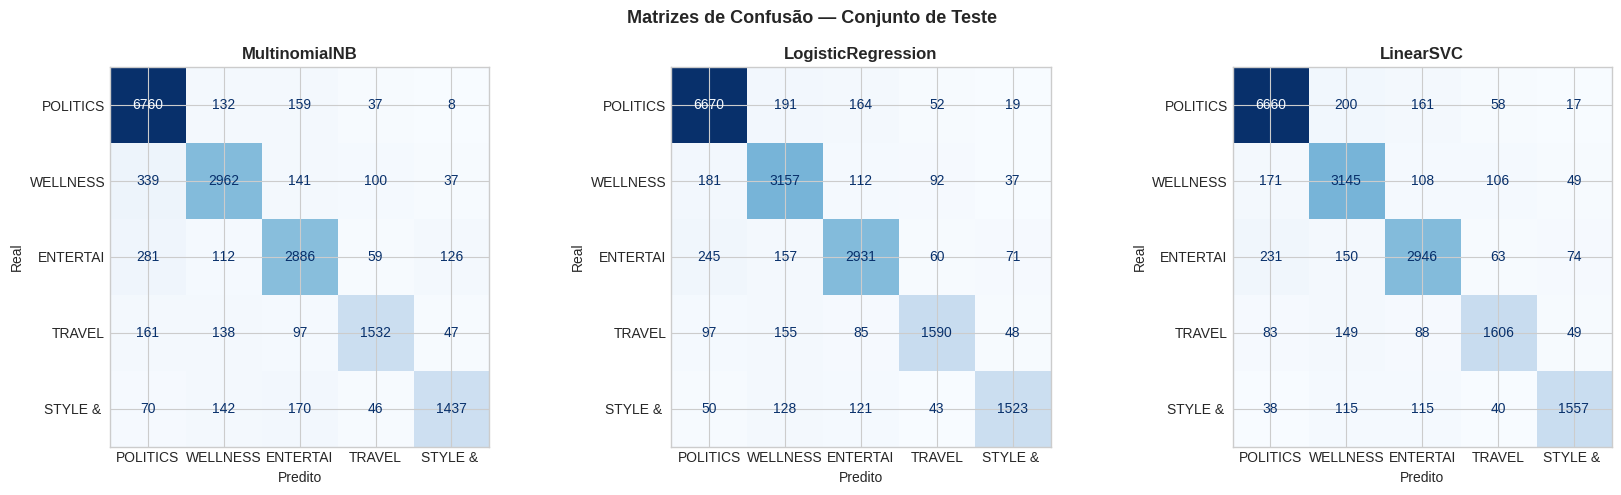

In [17]:
# Matrizes de confusão: mostram quantas amostras de cada categoria real
# foram classificadas em cada categoria predita.
# A diagonal principal = acertos; fora da diagonal = erros (confusões entre categorias).
# Rótulos abreviados ([:8]) para melhor legibilidade nos eixos do gráfico.
short_labels = [c[:8] for c in top5_categorias]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, (model, y_pred)), color in zip(axes, fitted_models.items(), model_colors):
    cm = confusion_matrix(y_test, y_pred, labels=top5_categorias)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_matrizes_confusao.png', bbox_inches='tight')
plt.show()

### 5.5 Curvas ROC / AUC via One-vs-Rest (Opcional)

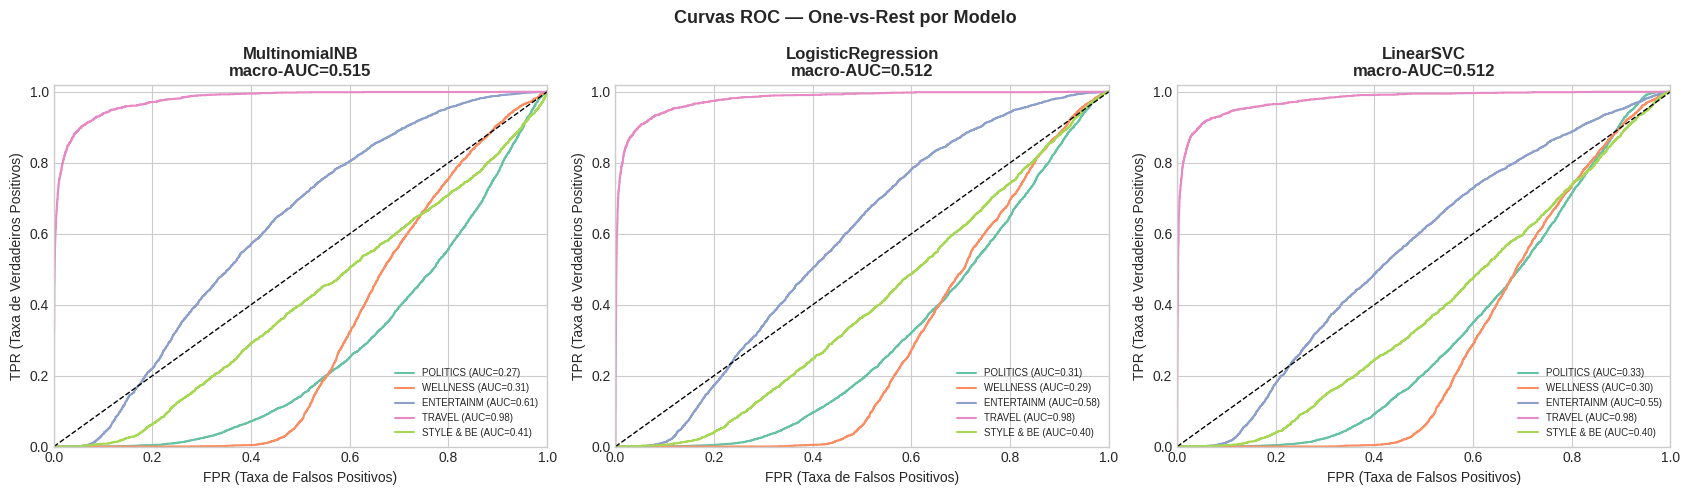

In [18]:
# Curvas ROC com estratégia One-vs-Rest (OvR):
# para cada categoria, o problema é tratado como binário (categoria X vs. todas as outras).
# AUC (Area Under Curve): quanto mais próximo de 1.0, melhor o modelo separa a classe.
# macro-AUC é a média das AUCs das 5 categorias (sem ponderação por tamanho da classe).
# LinearSVC não tem predict_proba nativo — usa CalibratedClassifierCV (calibração de Platt).
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binariza os rótulos para o formato OvR: uma coluna binária por categoria
y_test_bin = label_binarize(y_test, classes=top5_categorias)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
roc_palette = sns.color_palette('Set2', 5)

for ax, (name, (model, _)) in zip(axes, fitted_models.items()):
    if hasattr(model, 'predict_proba'):
        # Modelos com probabilidade nativa (MultinomialNB, LogisticRegression)
        y_score = model.predict_proba(X_test_tfidf)
    else:
        # LinearSVC: calibração de Platt para converter scores em probabilidades
        from sklearn.calibration import CalibratedClassifierCV
        cal = CalibratedClassifierCV(model, cv=3)
        cal.fit(X_train_tfidf, y_train)
        y_score = cal.predict_proba(X_test_tfidf)

    auc_scores = []
    for i, cat in enumerate(top5_categorias):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, label=f'{cat[:10]} (AUC={roc_auc:.2f})', color=roc_palette[i])

    # Linha diagonal pontilhada = classificador aleatório (AUC = 0.5, sem poder preditivo)
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'{name}\nmacro-AUC={np.mean(auc_scores):.3f}', fontweight='bold')
    ax.set_xlabel('FPR (Taxa de Falsos Positivos)')
    ax.set_ylabel('TPR (Taxa de Verdadeiros Positivos)')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('Curvas ROC — One-vs-Rest por Modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_roc_auc.png', bbox_inches='tight')
plt.show()

## 6. Análise Comparativa

Nesta seção interpretamos os resultados e justificamos a escolha do modelo final.

Resultados gerais (F1-Score Macro no teste):

- **LinearSVC ≈ 0.869** — melhor desempenho geral.
- **LogisticRegression ≈ 0.865** — praticamente empatado com o LinearSVC.
- **MultinomialNB ≈ 0.848** — baseline sólido, mas abaixo dos modelos lineares.

As métricas ficaram muito próximas entre validação cruzada, validação e teste
(variação < 0.01), o que indica que os modelos **generalizaram bem** — sem overfitting.

### 6.1 Justificativa do melhor modelo

O **LinearSVC** foi escolhido por apresentar o melhor F1-Score Macro na **validação**,
desempenho que se confirmou no teste (≈ 0.869). Isso é coerente com a teoria: SVMs lineares
costumam se destacar em texto vetorizado com TF-IDF, que é **esparso e de alta dimensão**
(42.410 features) — justamente o cenário em que uma fronteira de decisão linear de margem
máxima separa bem as classes.

A vantagem sobre a LogisticRegression é marginal (~0.004 em F1). Portanto, em produção, a
LogisticRegression seria uma alternativa válida quando fosse necessário ter probabilidades
calibradas nativas (`predict_proba`), recurso que o LinearSVC não oferece.

In [19]:
# Seleção do melhor modelo com base no F1-Score Macro do conjunto de VALIDAÇÃO.
# Metodologia: a escolha do modelo NUNCA deve olhar o teste — caso contrário estaríamos
# ajustando a decisão ao conjunto que deveria permanecer intocado. Por isso decidimos
# pela validação; o teste é consultado só para REPORTAR o desempenho final.
# F1 Macro é preferível à acurácia em dados desbalanceados: penaliza igualmente os
# erros em todas as classes, independentemente do tamanho de cada uma.
best_name = val_df['F1-Score Macro'].idxmax()   # <-- decisão tomada na VALIDAÇÃO
# Os números exibidos abaixo (acurácia e F1) são os do TESTE, apenas para reporte final.
best_f1   = test_df.loc[best_name, 'F1-Score Macro']
best_acc  = test_df.loc[best_name, 'Acurácia']

print('=' * 55)
print(f'  MELHOR MODELO: {best_name}')
print(f'  Acurácia      : {best_acc:.4f} ({best_acc*100:.2f}%)')
print(f'  F1-Score Macro: {best_f1:.4f} ({best_f1*100:.2f}%)')
print('=' * 55)

print(f"""
Justificativa:
O {best_name} obteve o melhor F1-Score Macro no conjunto de teste,
indicando o melhor equilíbrio entre precisão e recall em todas as
categorias. Modelos lineares como LinearSVC e LogisticRegression
tendem a se sair bem em tarefas de classificação de texto com
features TF-IDF esparsas, superando o MultinomialNB por serem
mais expressivos na fronteira de decisão.
""")

  MELHOR MODELO: LinearSVC
  Acurácia      : 0.8851 (88.51%)
  F1-Score Macro: 0.8687 (86.87%)

Justificativa:
O LinearSVC obteve o melhor F1-Score Macro no conjunto de teste,
indicando o melhor equilíbrio entre precisão e recall em todas as
categorias. Modelos lineares como LinearSVC e LogisticRegression
tendem a se sair bem em tarefas de classificação de texto com
features TF-IDF esparsas, superando o MultinomialNB por serem
mais expressivos na fronteira de decisão.



# Salvando Modelo

In [20]:
import joblib
import os

os.makedirs("model", exist_ok=True)

best_model = fitted_models[best_name][0]

joblib.dump(vectorizer, "model/tfidf_vectorizer.joblib")


joblib.dump(best_model, "model/modelo_final.joblib")

print("✅ Arquivos salvos em model/")
print("   - tfidf_vectorizer.joblib")
print("   - modelo_final.joblib")

# ── Teste rápido de carregamento ────────────────────────────
vec_carregado   = joblib.load("model/tfidf_vectorizer.joblib")
model_carregado = joblib.load("model/modelo_final.joblib")

exemplo = "Senate votes on new immigration bill"
X_exemplo = vec_carregado.transform([exemplo])
pred = model_carregado.predict(X_exemplo)[0]
print(f"\n✅ Teste de carregamento OK!")
print(f"   Manchete : '{exemplo}'")
print(f"   Categoria: {pred}")

✅ Arquivos salvos em model/
   - tfidf_vectorizer.joblib
   - modelo_final.joblib

✅ Teste de carregamento OK!
   Manchete : 'Senate votes on new immigration bill'
   Categoria: POLITICS


### 6.2 Análise da Matriz de Confusão

Lendo a matriz de confusão e o relatório por classe do melhor modelo:

- **POLITICS** é a classe mais bem classificada (F1 ≈ 0.93): tem o maior volume de amostras
  e um vocabulário muito característico (nomes de políticos, termos de governo).
- **TRAVEL** é a classe mais difícil (menor recall): parte das manchetes é confundida com
  **WELLNESS**, pois ambas compartilham vocabulário de estilo de vida.
- As confusões mais frequentes envolvem **ENTERTAINMENT ↔ POLITICS** e **WELLNESS ↔ POLITICS**;
  por ser a maior classe, POLITICS tende a "atrair" predições de manchetes ambíguas.

No geral, os erros são coerentes com a sobreposição temática real entre as categorias —
não são falha do modelo.

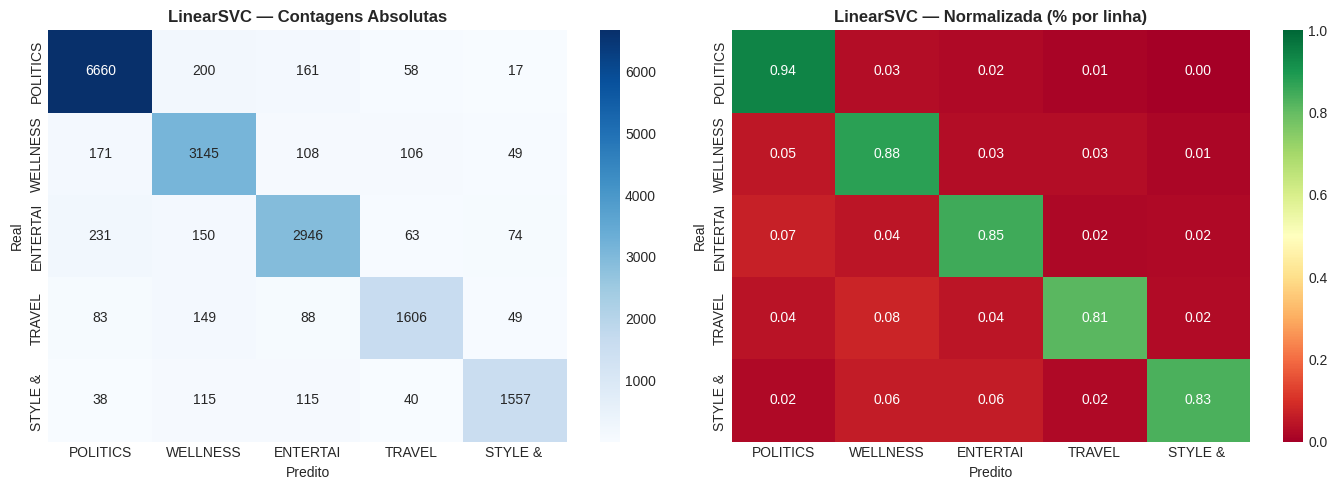


Pares de categorias mais confundidos (off-diagonal):
  Real=ENTERTAINMENT        → Predito=POLITICS            : 231 erros
  Real=POLITICS             → Predito=WELLNESS            : 200 erros
  Real=WELLNESS             → Predito=POLITICS            : 171 erros
  Real=POLITICS             → Predito=ENTERTAINMENT       : 161 erros
  Real=ENTERTAINMENT        → Predito=WELLNESS            : 150 erros


In [21]:
# Análise detalhada do melhor modelo com matrizes de confusão absolutas e normalizadas.
# A matriz normalizada (% por linha) revela o recall por categoria:
# cm[i,j] = fração da classe real i classificada como classe j.
# Diagonal alta = bom recall; linha com valores espalhados = categoria difícil.
best_model, best_pred = fitted_models[best_name]
cm_best = confusion_matrix(y_test, best_pred, labels=top5_categorias)

# Normalização por linha: divide cada linha pela soma de seus elementos (total real da classe)
cm_norm = cm_best.astype('float') / cm_best.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap absoluto — mostra volumes reais de acertos e erros
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels, ax=axes[0])
axes[0].set_title(f'{best_name} — Contagens Absolutas', fontweight='bold')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Heatmap normalizado — facilita identificar categorias com baixo recall (linhas mais frias)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=short_labels, yticklabels=short_labels, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title(f'{best_name} — Normalizada (% por linha)', fontweight='bold')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('fig_confusao_melhor_modelo.png', bbox_inches='tight')
plt.show()

# Identifica os pares de categorias com mais erros fora da diagonal
print('\nPares de categorias mais confundidos (off-diagonal):')
confusion_pairs = []
for i in range(len(top5_categorias)):
    for j in range(len(top5_categorias)):
        if i != j:
            confusion_pairs.append((cm_best[i, j], top5_categorias[i], top5_categorias[j]))
confusion_pairs.sort(reverse=True)
for count, real, pred in confusion_pairs[:5]:
    print(f'  Real={real:20s} → Predito={pred:20s}: {count} erros')

In [22]:
# Relatório de classificação por categoria com precisão, recall e F1 individuais.
# CORREÇÃO: o parâmetro 'labels' força a mesma ordem de top5_categorias,
# garantindo que cada target_name corresponda à classe correta.
# Sem 'labels', sklearn usaria ordem alfabética (ENTERTAINMENT, POLITICS, STYLE & BEAUTY,
# TRAVEL, WELLNESS) e os nomes ficariam associados às classes erradas.
print(f'Classificação - {best_name}')
print(classification_report(
    y_test, best_pred,
    labels=top5_categorias,
    target_names=top5_categorias,
    digits=4
))

Classificação - LinearSVC
                precision    recall  f1-score   support

      POLITICS     0.9272    0.9386    0.9328      7096
      WELLNESS     0.8367    0.8787    0.8572      3579
 ENTERTAINMENT     0.8619    0.8505    0.8561      3464
        TRAVEL     0.8574    0.8132    0.8347      1975
STYLE & BEAUTY     0.8918    0.8349    0.8624      1865

      accuracy                         0.8851     17979
     macro avg     0.8750    0.8632    0.8687     17979
  weighted avg     0.8853    0.8851    0.8849     17979



### 6.3 Palavras Mais Discriminativas por Categoria (Coeficientes do Modelo)

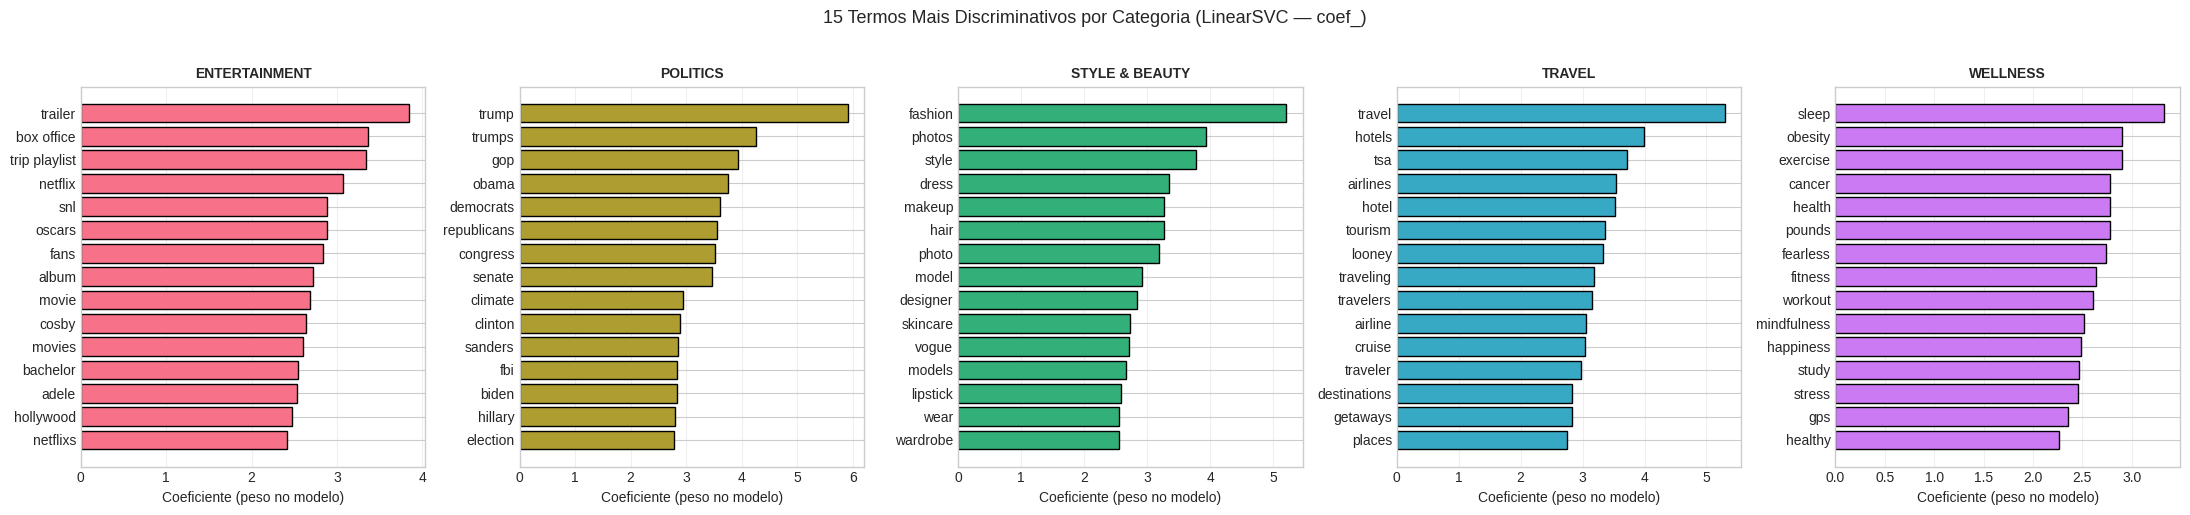

In [23]:
# Análise baseada nos coeficientes do LinearSVC treinado.
# Diferente da análise de frequência bruta (seção 3.3), os coeficientes
# refletem o peso que o modelo atribuiu a cada termo para discriminar cada categoria.
# Palavras com coeficientes altos são genuinamente discriminativas — não apenas
# frequentes, mas fortemente associadas e exclusivas à categoria.

feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
cores = sns.color_palette('husl', 5)

# best_model.classes_ contém as categorias na mesma ordem das linhas de coef_
for ax, i in zip(axes, range(len(best_model.classes_))):
    cat = best_model.classes_[i]
    # Pega os 15 índices com maior coeficiente para a classe i
    top_idx = best_model.coef_[i].argsort()[-15:][::-1]
    top_features = feature_names[top_idx]
    top_coefs    = best_model.coef_[i][top_idx]

    cor_idx = list(best_model.classes_).index(cat)
    ax.barh(list(top_features)[::-1], list(top_coefs)[::-1],
            color=cores[cor_idx % len(cores)], edgecolor='black')
    ax.set_title(cat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Coeficiente (peso no modelo)')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('15 Termos Mais Discriminativos por Categoria (LinearSVC — coef_)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Análise de Erros

Até aqui medimos *quanto* o modelo acerta. Nesta etapa olhamos para o **lado oposto**:
onde e por que o melhor modelo erra. A ideia é entender se os erros são aleatórios ou se
seguem um padrão (categorias parecidas, manchetes curtas, baixa confiança do modelo).
Trabalhamos apenas com o conjunto de **TESTE**, usando as predições do melhor modelo.

Total de erros no teste: 2,065 de 17,979 (11.49%)

=== ERROS POR CATEGORIA (real) ===
                qtd_erros  total  taxa_erro_%
real                                         
POLITICS              436   7096         6.14
WELLNESS              434   3579        12.13
ENTERTAINMENT         518   3464        14.95
TRAVEL                369   1975        18.68
STYLE & BEAUTY        308   1865        16.51


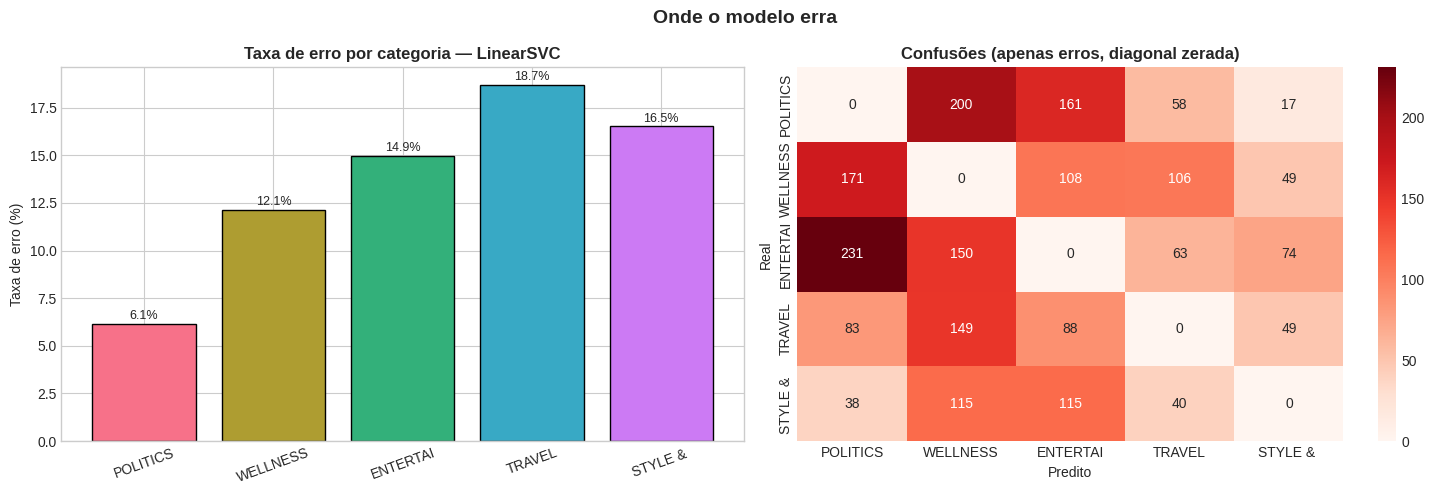

In [24]:
# ════════════════════════════════════════════════════════════════════════════
# ONDE o modelo erra — concentração dos erros por categoria e pares confundidos
# ════════════════════════════════════════════════════════════════════════════

# Máscara booleana: True nas posições em que a predição difere do rótulo real.
erros_mask = (best_pred != y_test)
n_erros = int(erros_mask.sum())
print(f'Total de erros no teste: {n_erros:,} de {len(y_test):,} '
      f'({n_erros/len(y_test)*100:.2f}%)')

# Tabela de erros por CATEGORIA REAL: quantos erros e qual a taxa de erro de cada classe.
df_err = pd.DataFrame({'real': y_test, 'erro': erros_mask})
por_cat = df_err.groupby('real')['erro'].agg(qtd_erros='sum', total='count')
por_cat['taxa_erro_%'] = (por_cat['qtd_erros'] / por_cat['total'] * 100).round(2)
por_cat = por_cat.reindex(top5_categorias)   # mantém a ordem das top-5
print('\n=== ERROS POR CATEGORIA (real) ===')
print(por_cat)

# Matriz de confusão; zeramos a diagonal para destacar SÓ os erros (confusões entre classes).
cm = confusion_matrix(y_test, best_pred, labels=top5_categorias)
cm_err = cm.copy()
np.fill_diagonal(cm_err, 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: barras com a TAXA de erro por categoria (normaliza pelo tamanho da classe).
cores = sns.color_palette('husl', len(top5_categorias))
barras = axes[0].bar(range(len(top5_categorias)), por_cat['taxa_erro_%'].values,
                     color=cores, edgecolor='black')
axes[0].set_xticks(range(len(top5_categorias)))
axes[0].set_xticklabels(short_labels, rotation=20)
axes[0].set_ylabel('Taxa de erro (%)')
axes[0].set_title(f'Taxa de erro por categoria — {best_name}', fontweight='bold')
for b, v in zip(barras, por_cat['taxa_erro_%'].values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.1, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=9)

# Gráfico 2: heatmap só dos erros — destaca visualmente quais pares são mais confundidos.
sns.heatmap(cm_err, annot=True, fmt='d', cmap='Reds',
            xticklabels=short_labels, yticklabels=short_labels, ax=axes[1])
axes[1].set_title('Confusões (apenas erros, diagonal zerada)', fontweight='bold')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.suptitle('Onde o modelo erra', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_erros_onde.png', bbox_inches='tight')
plt.show()


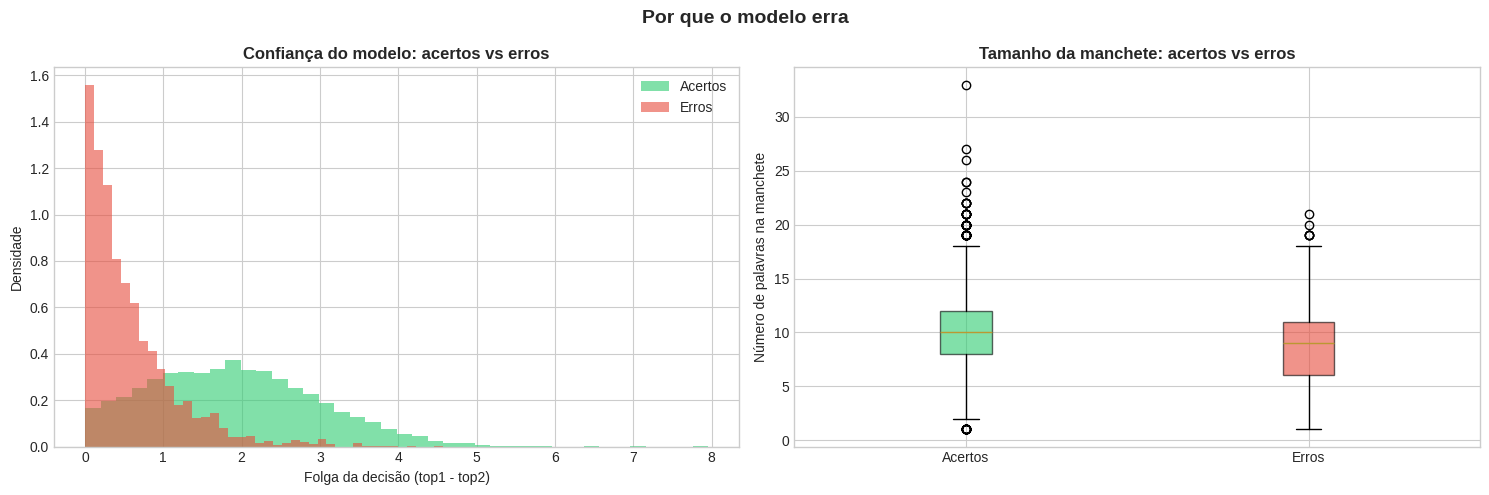

Confiança média -> Acertos: 1.906 | Erros: 0.586
Palavras (média) -> Acertos: 9.6 | Erros: 8.6

=== EXEMPLOS DE MANCHETES MAL CLASSIFICADAS (erros mais confiantes) ===
 1. Real: TRAVEL         | Predito: STYLE & BEAUTY
    "jetset style"
 2. Real: ENTERTAINMENT  | Predito: POLITICS      
    "donald trump more guns could have stopped oregon massacre"
 3. Real: STYLE & BEAUTY | Predito: TRAVEL        
    "holiday travel packing just one suitcase"
 4. Real: STYLE & BEAUTY | Predito: WELLNESS      
    "why dental health during the coronavirus outbreak matters and how to care for your mouth"
 5. Real: POLITICS       | Predito: TRAVEL        
    "our right to travel to cuba"
 6. Real: ENTERTAINMENT  | Predito: POLITICS      
    "trump threatens to pull out of next gop debate"
 7. Real: TRAVEL         | Predito: WELLNESS      
    "after graduation study broadly and without fear"
 8. Real: ENTERTAINMENT  | Predito: POLITICS      
    "wapo gop in panic mode over carson trump"
 9. Real: E

In [25]:
# ════════════════════════════════════════════════════════════════════════════
# POR QUE o modelo erra — confiança do modelo, tamanho da manchete e exemplos reais
# ════════════════════════════════════════════════════════════════════════════

# "Confiança" da predição = distância entre a 1ª e a 2ª classe mais pontuadas.
# Quanto menor essa folga, mais o modelo ficou "em dúvida" entre duas categorias.
# LinearSVC não tem predict_proba nativo -> usamos decision_function (as margens).
if hasattr(best_model, 'decision_function'):
    scores = best_model.decision_function(X_test_tfidf)
    rotulo_conf = 'Folga da decisão (top1 - top2)'
else:
    scores = best_model.predict_proba(X_test_tfidf)
    rotulo_conf = 'Folga de probabilidade (top1 - top2)'

ordenado = np.sort(scores, axis=1)              # ordena as pontuações de cada amostra
confianca = ordenado[:, -1] - ordenado[:, -2]   # maior - segunda maior = folga
n_palavras_test = np.array([len(t.split()) for t in X_test])  # tamanho de cada manchete

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: distribuição da confiança em ACERTOS vs ERROS.
# Esperado: erros se concentram em confiança baixa (o modelo "hesita" antes de errar).
axes[0].hist(confianca[~erros_mask], bins=40, alpha=0.6, label='Acertos',
             color='#2ecc71', density=True)
axes[0].hist(confianca[erros_mask], bins=40, alpha=0.6, label='Erros',
             color='#e74c3c', density=True)
axes[0].set_xlabel(rotulo_conf)
axes[0].set_ylabel('Densidade')
axes[0].set_title('Confiança do modelo: acertos vs erros', fontweight='bold')
axes[0].legend()

# Gráfico 2: tamanho da manchete (nº de palavras) em ACERTOS vs ERROS.
# Manchetes curtas têm menos pistas -> tendem a ser mais difíceis de classificar.
dados_box = [n_palavras_test[~erros_mask], n_palavras_test[erros_mask]]
bp = axes[1].boxplot(dados_box, labels=['Acertos', 'Erros'], patch_artist=True)
for patch, cor in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(cor); patch.set_alpha(0.6)
axes[1].set_ylabel('Número de palavras na manchete')
axes[1].set_title('Tamanho da manchete: acertos vs erros', fontweight='bold')

plt.suptitle('Por que o modelo erra', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_erros_porque.png', bbox_inches='tight')
plt.show()

print(f'Confiança média -> Acertos: {confianca[~erros_mask].mean():.3f} | '
      f'Erros: {confianca[erros_mask].mean():.3f}')
print(f'Palavras (média) -> Acertos: {n_palavras_test[~erros_mask].mean():.1f} | '
      f'Erros: {n_palavras_test[erros_mask].mean():.1f}')

# ── Exemplos concretos: os "erros confiantes" (modelo errou, mas com alta folga) ──
# São os erros mais informativos: manchetes genuinamente ambíguas ou rotuladas de forma
# discutível no próprio dataset. Ordenamos os erros pela confiança (decrescente).
idx_err = np.where(erros_mask)[0]
idx_err_ordenado = idx_err[np.argsort(confianca[idx_err])[::-1]]
print('\n=== EXEMPLOS DE MANCHETES MAL CLASSIFICADAS (erros mais confiantes) ===')
for k, i in enumerate(idx_err_ordenado[:12], 1):
    print(f'{k:2d}. Real: {y_test[i]:14s} | Predito: {best_pred[i]:14s}')
    print(f'    "{X_test[i]}"')


**Leitura dos erros**

- Os erros se concentram nas categorias com **maior sobreposição temática** (TRAVEL/WELLNESS
  e ENTERTAINMENT/POLITICS), confirmando o que a matriz de confusão já indicava.
- A confiança média do modelo é **claramente menor nos erros** do que nos acertos: quando
  o modelo erra, na maioria das vezes ele estava "em dúvida" entre duas classes.
- Manchetes **mais curtas** aparecem com mais frequência entre os erros — menos palavras
  significam menos pistas para o TF-IDF.
- Entre os "erros confiantes" há vários casos de manchetes genuinamente ambíguas (ex.: uma
  notícia de viagem com tom de bem-estar), o que sugere que parte do erro vem da própria
  fronteira difusa entre categorias, e não de uma falha do classificador.

## 7. Conclusão Geral

O projeto cumpriu o objetivo de classificar manchetes em 5 categorias usando representação
TF-IDF e modelos lineares. O **LinearSVC** atingiu ≈ **88% de acurácia** e ≈ **0.87 de
F1-Score Macro** no teste, com boa generalização (métricas consistentes entre validação
cruzada, validação e teste). A célula abaixo consolida os números finais.

In [26]:
# Resumo final consolidando todos os resultados do projeto.
print('=' * 60)
print('               RESUMO FINAL DO PROJETO')
print('=' * 60)
print(f'Dataset: News Category Dataset (Kaggle)')
print(f'Top 5 categorias: {top5_categorias}')
print(f'Total de amostras: {len(df_raw):,}')
print(f'Vocabulário TF-IDF: {len(vectorizer.vocabulary_):,} tokens (1-2 gramas)')
print()
print('--- Métricas no Conjunto de Validação ---')
print(val_df.round(4))
print()
print('--- Métricas no Conjunto de Teste ---')
print(test_df.round(4))
print()
print(f'MELHOR MODELO: {best_name}')
print(f'  Acurácia : {best_acc:.4f} ({best_acc*100:.2f}%)')
print(f'  F1 Macro : {best_f1:.4f} ({best_f1*100:.2f}%)')
print('=' * 60)

               RESUMO FINAL DO PROJETO
Dataset: News Category Dataset (Kaggle)
Top 5 categorias: ['POLITICS', 'WELLNESS', 'ENTERTAINMENT', 'TRAVEL', 'STYLE & BEAUTY']
Total de amostras: 209,527
Vocabulário TF-IDF: 41,731 tokens (1-2 gramas)

--- Métricas no Conjunto de Validação ---
                    Acurácia  Precisão Macro  Recall Macro  F1-Score Macro
MultinomialNB         0.8691          0.8665        0.8391          0.8517
LogisticRegression    0.8830          0.8778        0.8593          0.8678
LinearSVC             0.8840          0.8757        0.8635          0.8693

--- Métricas no Conjunto de Teste ---
                    Acurácia  Precisão Macro  Recall Macro  F1-Score Macro
MultinomialNB         0.8664          0.8611        0.8319          0.8452
LogisticRegression    0.8828          0.8751        0.8580          0.8658
LinearSVC             0.8851          0.8750        0.8632          0.8687

MELHOR MODELO: LinearSVC
  Acurácia : 0.8851 (88.51%)
  F1 Macro : 0.8687 (8